# Homework 1

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

2.16.2


# Use this random one dimensional dataset

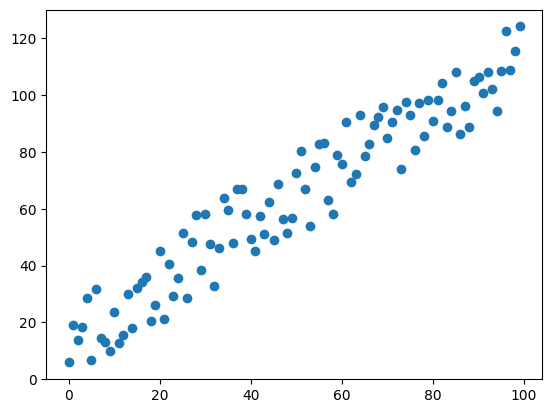

In [57]:
x = np.arange(0,100)
y = x + np.random.rand(100) * 30
plt.scatter(x,y)
plt.show()

# Problem 1
### a) Fit a regression line on the dataset created above using sklearn.linear_model LinearRegression, use default hyperparameters
### b) Print out the regression intercept and coefficients
### c) Plot the data in blue and the regression line in red
### d) Predict the y value for x=45 and show it on the plot in green

In [58]:
# a
from sklearn.linear_model import LinearRegression

X = x.reshape(-1, 1)
y_vec = y.astype(float)
# default hyperparameters
linreg = LinearRegression()
linreg.fit(X, y_vec)

LinearRegression()

In [59]:
# b
print("Intercept:", linreg.intercept_)
print("Coefficient:", linreg.coef_[0])

Intercept: 13.339674116591539
Coefficient: 1.0250471547772917


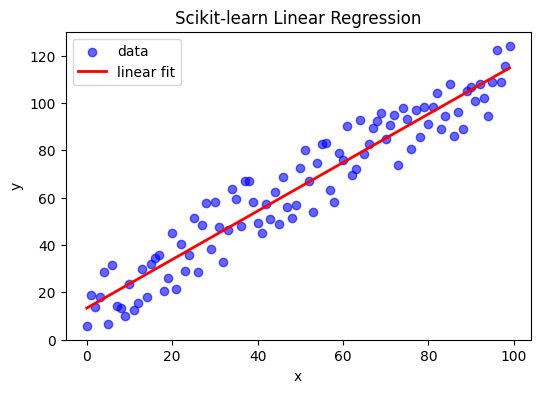

In [60]:
# c
x_line = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_line = linreg.predict(x_line)

plt.figure(figsize=(6,4))
plt.scatter(x, y, color="blue", alpha=0.6, label="data")
plt.plot(x_line, y_line, color="red", linewidth=2, label="linear fit")
plt.title("Scikit-learn Linear Regression")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

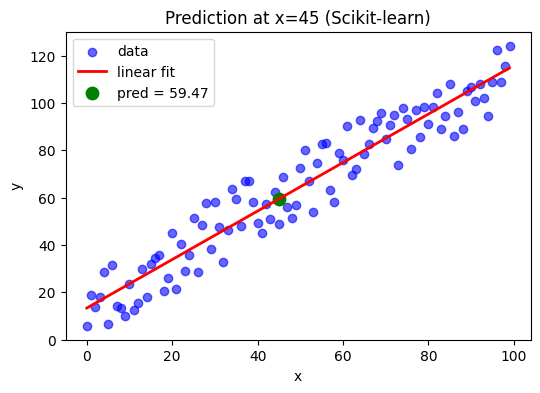

Predicted Y (x=45): 59.4668


In [61]:
# d
x_star = np.array([[45.0]])
y_hat = linreg.predict(x_star)[0]

plt.figure(figsize=(6,4))
plt.scatter(x, y, color="blue", alpha=0.6, label="data")
plt.plot(x_line, y_line, color="red", linewidth=2, label="linear fit")
plt.scatter([45], [y_hat], color="green", s=80, label=f"pred = {y_hat:.2f}")
plt.title("Prediction at x=45 (Scikit-learn)")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

print(f"Predicted Y (x=45): {y_hat:.4f}")

# Problem 2
### a) Fit a regression line on the dataset created above using tensorflow and keras, use default hyperparameters, sequential model, one dense neuron, activation='linear'.  Use 'rmsprop' optimizer and mean squared error for the loss function.  Use 1000 epochs.
### b) Print out the regression intercept and coefficients
### c) Plot the data in blue and the regression line in red
### d) Predict the y value for x=45 and show it on the plot in green
### e) Print the coefficients in the keras model and compare to the scikit learn modelen


In [62]:
# a
X_keras = x.astype("float32").reshape(-1, 1)
y_keras = y.astype("float32")

keras_reg = keras.Sequential([
    layers.Dense(1, activation="linear", input_shape=(1,))
])

keras_reg.compile(optimizer="rmsprop", loss="mse")
history = keras_reg.fit(X_keras, y_keras, epochs=1000, batch_size=16, verbose=0)
print("MSE:", history.history["loss"][-1])

/Users/magmac/Downloads/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MSE: 96.2534408569336


In [63]:
# b
W, b = keras_reg.layers[0].get_weights()
keras_coef = float(W[0,0])
keras_intercept = float(b[0])
print("Intercept:", keras_intercept)
print("Coefficient:", keras_coef)

Intercept: 5.165031433105469
Coefficient: 1.1499266624450684


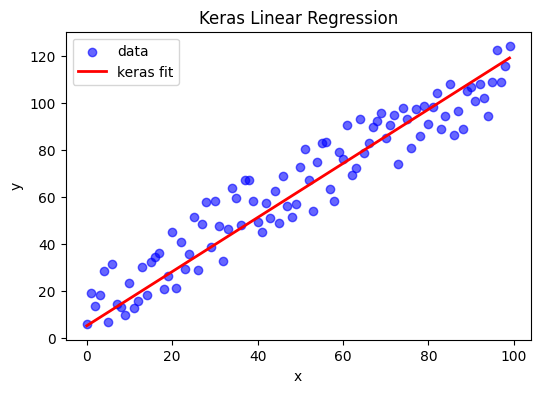

In [64]:
# c
x_line = np.linspace(x.min(), x.max(), 200, dtype="float32").reshape(-1, 1)
y_line_keras = keras_reg.predict(x_line, verbose=0).ravel()

plt.figure(figsize=(6,4))
plt.scatter(x, y, color="blue", alpha=0.6, label="data")
plt.plot(x_line, y_line_keras, color="red", linewidth=2, label="keras fit")
plt.title("Keras Linear Regression")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

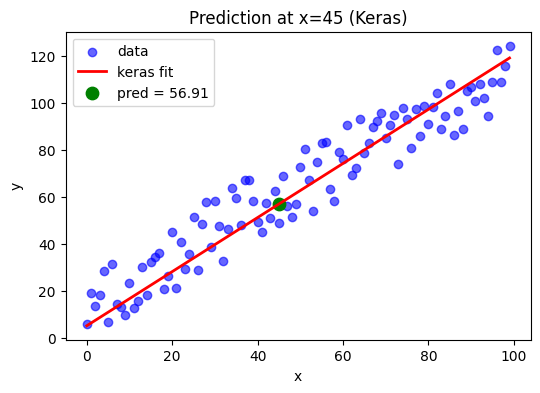

Predicted Y (x=45): 56.9117


In [65]:
# d
x_star = np.array([[45.0]], dtype="float32")
y_hat_keras = float(keras_reg.predict(x_star, verbose=0).ravel()[0])

plt.figure(figsize=(6,4))
plt.scatter(x, y, color="blue", alpha=0.6, label="data")
plt.plot(x_line, y_line_keras, color="red", linewidth=2, label="keras fit")
plt.scatter([45], [y_hat_keras], color="green", s=80, label=f"pred = {y_hat_keras:.2f}")
plt.title("Prediction at x=45 (Keras)")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

print(f"Predicted Y (x=45): {y_hat_keras:.4f}")

In [66]:
# e
diff_intercept = keras_intercept - linreg.intercept_
diff_coef = keras_coef - linreg.coef_[0]

print("Coefficient comparison:")
print(f"sklearn:  b0{linreg.intercept_: .5f} | b1{linreg.coef_[0]: .6f}")
print(f"keras:    b0{keras_intercept: .6f} | b1{keras_coef: .6f}")

Coefficient comparison:
sklearn:  b0 13.33967 | b1 1.025047
keras:    b0 5.165031 | b1 1.149927
